# Diagnosis Patterns in Hospital Encounters
### Comparing Diagnosis Codes Across Three Recorded Positions



## Research Question

How do the frequencies of diagnosis codes 428, 276, and 250 differ across the principal and two secondary diagnosis positions?

## Data Source

I used the diabetes dataset provided for the class and loaded it from the DataAnalyticsAcademy GitHub repository.

The dataset contains 101,766 hospital encountrs and 50 columns. Each row represents one encounter, and the same patient may appear more than once.

This analysis focuses on three columns:
-'diag_1': principal diagnosis
-'diag_2': secondary diagnosis
-'diag_3': an additional secondary diagnosis.

The diagnosis positions do not represent levels of severity or stages of a disease.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')

## Data Exploration
This helped me understand hoe the data was organized.

In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.shape

(101766, 50)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## Data Cleaning and Preparation

I selected the three diagnosis columns and created a copy to keep the original dataset unchanged.

I found that missing diagnoses were represented by "?". There were 21 missing entries in 'diag_1', 358 in 'diag_2', and 1,423 in 'diag_3'.

Finally I repleced them.

In [15]:
df[['diag_1', 'diag_2', 'diag_3']].head(10)

,diag_1,diag_2,diag_3
0,250.83,?,?
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250
6,414,411,V45
7,428,492,250
8,398,427,38
9,434,198,486


In [22]:
diagnoses = df[['diag_1', 'diag_2', 'diag_3']].copy()

In [24]:
(diagnoses == '?').sum()

,0
diag_1,21
diag_2,358
diag_3,1423


In [25]:
diagnoses = diagnoses.replace('?', pd.NA)

In [26]:
diagnoses.isna().sum()

,0
diag_1,21
diag_2,358
diag_3,1423


In [33]:
diagnoses = df[['diag_1', 'diag_2', 'diag_3']].copy()

In [34]:
diagnoses = diagnoses.replace('?', pd.NA)

In [35]:
diagnoses.shape

(101766, 3)

In [36]:
diagnoses['diag_1'].value_counts().head(10)

,count
diag_1,
428,6862
414,6581
786,4016
410,3614
486,3508
427,2766
491,2275
715,2151
682,2042


In [37]:
diagnoses['diag_2'].value_counts().head(10)

,count
diag_2,
276,6752
428,6662
250,6071
427,5036
401,3736
496,3305
599,3288
403,2823
414,2650


In [38]:
diagnoses['diag_3'].value_counts().head(10)

,count
diag_3,
250,11555
401,8289
276,5175
428,4577
427,3955
414,3664
496,2605
403,2357
585,1992


## Data Analysis
## Most Frequent Codes by Diagnosis Position

The diagnosis codes in each column separately to identify the most frequent codes in each position. Missing values were excluded from these counts.

Code 428 was the most frequent principal diagnosis, with 6,862 encounters. Code 276 was the most frequent in the second position, with 6,752 encounters. Code 250 was the most frequent in the third position, with 11,555 encounters.

In [39]:
frequencies = pd.DataFrame({'diag_1': diagnoses['diag_1'].value_counts(),
                            'diag_2': diagnoses['diag_2'].value_counts(),
                            'diag_3': diagnoses['diag_3'].value_counts()})

In [40]:
frequencies = frequencies.fillna(0).astype(int)

In [41]:
frequencies.loc[['428', '276', '250']]

,diag_1,diag_2,diag_3
428,6862,6662,4577
276,1889,6752,5175
250,235,6071,11555


### Visual Comparison

-The bar chart shows the differences between counts side by side.

-The line graph makes each code's pattern across positions easier to follow. Its lines connect categories and do not represent cahnges over time.

Both graphs shows that code 428 was more common in the principal position, code 276 was more common in the second position, and 250 was more common in the third position.


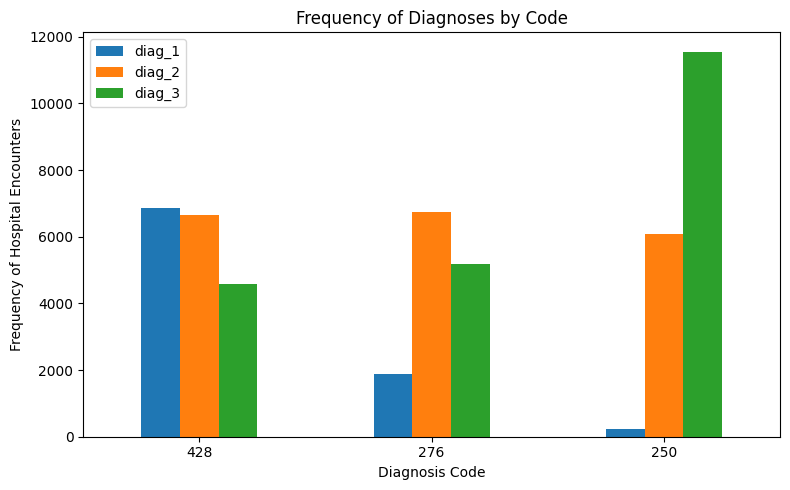

In [53]:
import matplotlib.pyplot as plt

frequencies.loc[['428', '276', '250']].plot.bar(figsize=(8, 5))

plt.title('Frequency of Diagnoses by Code')
plt.xlabel('Diagnosis Code')
plt.ylabel('Frequency of Hospital Encounters')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [54]:
frequencies.loc[['428', '276', '250']]

,diag_1,diag_2,diag_3
428,6862,6662,4577
276,1889,6752,5175
250,235,6071,11555


In [56]:
diagnoses.describe()

,diag_1,diag_2,diag_3
count,101745,101408,100343
unique,716,748,789
top,428,276,250
freq,6862,6752,11555


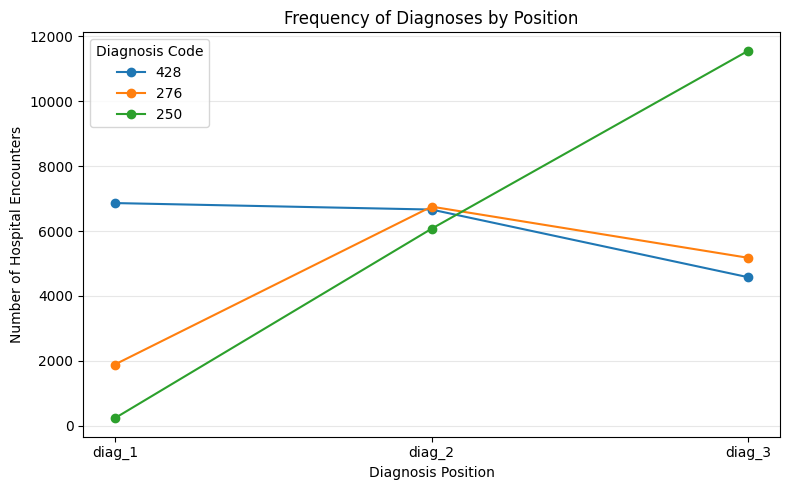

In [61]:
import matplotlib.pyplot as plt

frequencies.loc[['428', '276', '250']].T.plot(kind='line', marker='o', figsize=(8, 5))

plt.title('Frequency of Diagnoses by Position')
plt.xlabel('Diagnosis Position')
plt.ylabel('Number of Hospital Encounters')
plt.xticks([0,1,2],['diag_1', 'diag_2', 'diag_3'])
plt.legend(title='Diagnosis Code')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
diagnoses.describe()

,diag_1,diag_2,diag_3
count,101745,101408,100343
unique,716,748,789
top,428,276,250
freq,6862,6752,11555


## Conclusion

The analysis showed different diagnosis patterns across the three recorded positions. Code 428 was most common as the principal diagnosis, while codes 276 and 250 were most common in the second adn third positions, respectively. These results describe the frequency of exact diagnosis codes in hospital encounters, but they do not establish which condition is more likely to cause hospitalization.